In [945]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.pipeline import make_pipeline as make_imblearn_pipeline
from imblearn.under_sampling import RandomUnderSampler

In [946]:
data = pd.read_csv('Teen_Mental_Health_Dataset.csv')

In [947]:
cat_cols = [
    'gender', 
    'platform_usage', 
    'social_interaction_level'
]

num_col = [
    'age', 
    'daily_social_media_hours', 
    'sleep_hours', 
    'screen_time_before_sleep', 
    'academic_performance', 
    'physical_activity',
    
    'anxiety_level', 
    'addiction_level',
    'stress_level'
]

target_col = [
    'depression_label'
]


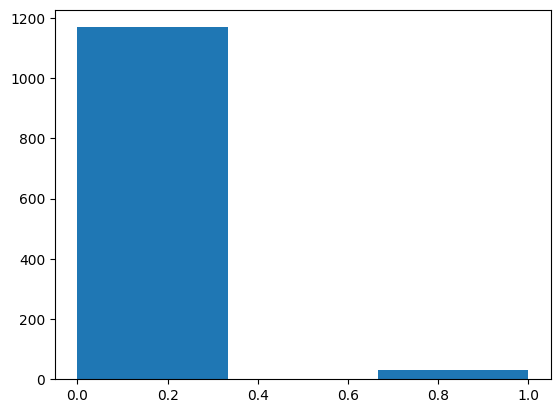

In [948]:
plt.hist(data[target_col], bins=3)
plt.show()

In [969]:
data

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [949]:
for i in num_col:
    print(data[i].corr(data['depression_label']))

0.01097253669426405
0.1752008073752394
-0.19062963227029991
-0.016501626671909936
0.0014407124846454351
-0.017597682694723622
0.1695661521916454
-0.0139520875339387
0.17047371335396663


In [965]:
data['academic_performance'].describe()

count    1200.000000
mean        2.990383
std         0.576758
min         2.000000
25%         2.500000
50%         2.990000
75%         3.480000
max         4.000000
Name: academic_performance, dtype: float64

In [951]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

In [952]:
preproc = ColumnTransformer(
    [
        ('cat', OrdinalEncoder(), cat_cols),
        ('nums', StandardScaler(), num_col)
    ]
)

In [953]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [954]:
model = DecisionTreeClassifier(random_state=42)
pipeline = make_imblearn_pipeline(preproc, SMOTE(random_state=42), model)

In [955]:
X = data[cat_cols + num_col]
y = data[target_col]

In [956]:
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y) 
pipeline.fit(X_train, y_train)
1

1

In [957]:
y_pred = pipeline.predict(X_val)
acc = accuracy_score(y_val, y_pred)


In [958]:
columns_test = ['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level']

In [1008]:
X_test = pd.DataFrame([[
    15, 'female', 12, 'Both', 3, 2, 2, 2, 'high', 10, 10, 10
]], columns=columns_test)

In [1009]:
print(pipeline.predict(X_test))

[1]


In [961]:
print(acc)


0.9958333333333333


In [962]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       0.86      1.00      0.92         6

    accuracy                           1.00       240
   macro avg       0.93      1.00      0.96       240
weighted avg       1.00      1.00      1.00       240



In [968]:
import joblib
joblib.dump(pipeline, 'D:\pet\django\MentalHealth\health\mental_health_model.pkl')

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Артем\AppData\Local\Temp\ipykernel_43876\409007542.py:2: SyntaxWarning: invalid escape sequence '\p'
  joblib.dump(pipeline, 'D:\pet\django\MentalHealth\health\mental_health_model.pkl')


['D:\\pet\\django\\MentalHealth\\health\\mental_health_model.pkl']